Baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from narwhals import Categorical
from narwhals.selectors import categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from lightgbm.callback import early_stopping, log_evaluation


import lightgbm as lgb

In [2]:
path_to_data = "/home/usl/PycharmProjects/home-credit-default-risk/data/raw/home-credit-default-risk/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
application_test_df = pd.read_csv(path_to_data+"application_test.csv")
sample_submission_df = pd.read_csv(path_to_data+"sample_submission.csv")

### Feature engineering

In [6]:
bureau_df = pd.read_csv(path_to_data+"bureau.csv")
bureau_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1716428 non-null  int64  
 1   SK_ID_BUREAU            1716428 non-null  int64  
 2   CREDIT_ACTIVE           1716428 non-null  object 
 3   CREDIT_CURRENCY         1716428 non-null  object 
 4   DAYS_CREDIT             1716428 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1716428 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1610875 non-null  float64
 7   DAYS_ENDDATE_FACT       1082775 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  591940 non-null   float64
 9   CNT_CREDIT_PROLONG      1716428 non-null  int64  
 10  AMT_CREDIT_SUM          1716415 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1458759 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1124648 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1716428 non-null  float64
 14  CR

In [12]:
bureau_df.groupby(["SK_ID_CURR", "CREDIT_ACTIVE"])[["SK_ID_BUREAU"]].count()

SK_ID_BUREAU
SK_ID_CURR CREDIT_ACTIVE              
100001     Active                    3
           Closed                    4
100002     Active                    2
           Closed                    6
100003     Active                    1
...                                ...
456253     Active                    2
           Closed                    2
456254     Closed                    1
456255     Active                    5
           Closed                    6

[525782 rows x 1 columns]

In [13]:
bureau_days_credit_mean = bureau_df.groupby("SK_ID_CURR")[["DAYS_CREDIT"]].mean()
bureau_days_credit_mean

,DAYS_CREDIT
SK_ID_CURR,
100001,-735.000000
100002,-874.000000
100003,-1400.750000
100004,-867.000000
100005,-190.666667
...,...
456249,-1667.076923
456250,-862.000000
456253,-867.500000


In [14]:
bureau_days_credit_median = bureau_df.groupby("SK_ID_CURR")[["DAYS_CREDIT"]].median()
bureau_days_credit_median

,DAYS_CREDIT
SK_ID_CURR,
100001,-857.0
100002,-1042.5
100003,-1205.5
100004,-867.0
100005,-137.0
...,...
456249,-1680.0
456250,-824.0
456253,-919.0


In [15]:
bureau_days_credit_mean.merge(bureau_days_credit_median, on="SK_ID_CURR")

,DAYS_CREDIT_x,DAYS_CREDIT_y
SK_ID_CURR,,
100001,-735.000000,-857.0
100002,-874.000000,-1042.5
100003,-1400.750000,-1205.5
100004,-867.000000,-867.0
100005,-190.666667,-137.0
...,...,...
456249,-1667.076923,-1680.0
456250,-862.000000,-824.0
456253,-867.500000,-919.0


Split into train and val

In [3]:
train_users = application_train_df["SK_ID_CURR"].unique()
train_ids, val_ids = train_test_split(train_users, test_size=0.2, random_state=42)
train_ids

array([243191, 111778, 175057, ..., 253016, 270275, 241394],
      shape=(246008,))

In [4]:
train_df = application_train_df[application_train_df.SK_ID_CURR.isin(train_ids)].copy()
val_df = application_train_df[application_train_df.SK_ID_CURR.isin(val_ids)].copy()

In [5]:
train_df.shape, val_df.shape

((246008, 122), (61503, 122))

In [6]:
application_train_df["TARGET"].mean(), train_df["TARGET"].mean(), val_df["TARGET"].mean()

(np.float64(0.08072881945686496),
 np.float64(0.08079412051640597),
 np.float64(0.08046761946571712))

In [7]:
drop_feat = ["SK_ID_CURR"]
train_df.drop(drop_feat, axis=1, inplace=True)
val_df.drop(drop_feat, axis=1, inplace=True)
application_test_df.drop(drop_feat, axis=1, inplace=True)

In [8]:
X_train = train_df.drop("TARGET", axis=1)
y_train = train_df["TARGET"]
X_val = val_df.drop("TARGET", axis=1)
y_val = val_df["TARGET"]

In [9]:
cat_cols = X_train.select_dtypes(include = 'object').columns.tolist()
len(cat_cols)

16

In [10]:
for col in cat_cols:
    categories = X_train[col].dropna().unique()
    X_train[col] = pd.Categorical(X_train[col], categories = categories)
    X_val[col] = pd.Categorical(X_val[col], categories = categories)


In [11]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

### LightGBM

In [12]:
lgb_clf = lgb.LGBMClassifier(n_estimators=1000, max_depth=4, learning_rate=0.1, random_state = 42, n_jobs=-1)
lgb_clf.fit(X_train, y_train, eval_set = [(X_val, y_val)], eval_metric='auc', categorical_feature=cat_cols, callbacks = [early_stopping(stopping_rounds=100), log_evaluation(period = 100)])

threshold = 0.5
val_pred_proba = lgb_clf.predict_proba(X_val)[:, 1]
val_pred = (val_pred_proba >= threshold).astype(int)


roc_auc_lgb = roc_auc_score(y_val, val_pred_proba)
prec_lgb = precision_score(y_val, val_pred, zero_division=0)
rec_lgb = recall_score(y_val, val_pred, zero_division=0)

print("Best_iteration:", lgb_clf.best_iteration_)
print("ROC-AUC_lgb:", roc_auc_lgb)
print("Precision_lgb:", prec_lgb)
print("Recall_lgb:", rec_lgb)

/home/usl/PycharmProjects/home-credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11315
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 116
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

Text(0.5, 1.0, 'Confusion Matrix LightGBM')

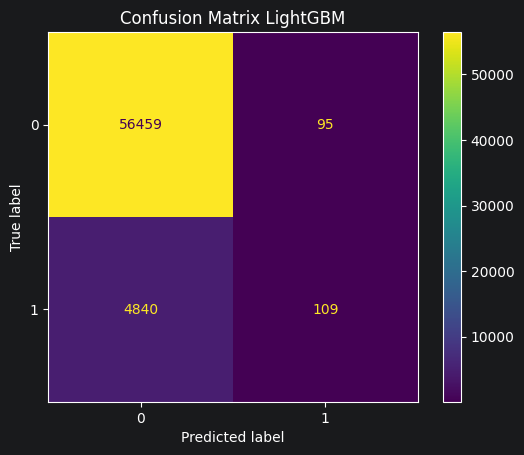

In [13]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Confusion Matrix LightGBM")

And now we will calculate the roc_curve and plot a graph:

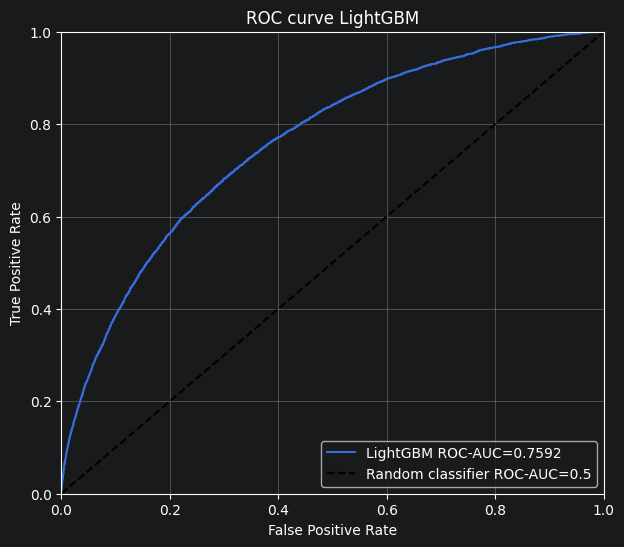

In [14]:
fpr, tpr, thresholds = roc_curve(y_val, val_pred_proba)
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label = f"LightGBM ROC-AUC={roc_auc_lgb:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label = "Random classifier ROC-AUC=0.5")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve LightGBM")
plt.legend(loc="lower right")
plt.grid()

We will prepare the test part for training:

In [15]:
application_test_df.shape

(48744, 120)

In [16]:
X_test = application_test_df

In [17]:
for col in cat_cols:
    X_test[col] = pd.Categorical(X_test[col], categories = X_train[col].cat.categories)
X_test.shape, X_train.shape

((48744, 120), (246008, 120))

In [18]:
list(X_train.columns) == list(X_test.columns)

True

In [19]:
test_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

In [20]:
submission = sample_submission_df.copy()
submission["TARGET"] = test_pred_proba
submission.head()

,SK_ID_CURR,TARGET
0,100001,0.041798
1,100005,0.141336
2,100013,0.039745
3,100028,0.039389
4,100038,0.147843


In [21]:
submission.shape, application_test_df.shape

((48744, 2), (48744, 120))

In [22]:
submission.to_csv("submission_lgb_baseline.csv", index=False)